In [77]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters 

Lx = 512
Ly = 10
K = 2 
J = 1 
W = 10

N = Lx * Ly 

print ("Total number of sites =", N)


Total number of sites = 5120


In [78]:
# Function to create one random T matrix 

np.random.seed(0)

def create_random_T(Ly, K):
    Tx = np.zeros((Ly, Ly), 
                  dtype=int)

    rows = np.arange(Ly)

    for k in range(K):
        Tx[(rows + k) % Ly, rows] = 1

    Tx = Tx[np.random.permutation(Ly)]
    Tx = Tx[:, np.random.permutation(Ly)]

    return Tx

# Create T matrices for all neighboring layers

T = []

for x in range(Lx - 1):
    Tx = create_random_T(Ly, K)
    T.append(Tx)
    # print(f"\nConnection matrix T({x+1}, {x+2})")
    # print(Tx)

print("Connection matrix")
print(T[0])

print("Row sums:", T[0].sum(axis=1))
print("Column sums:", T[0].sum(axis=0))


Connection matrix
[[0 0 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 1 0]
 [1 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 1 1 0 0 0 0]
 [0 0 1 0 0 0 1 0 0 0]
 [0 1 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 1 1 0]
 [1 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 1 0 1 0 0 0]
 [0 1 0 0 0 0 0 0 0 1]]
Row sums: [2 2 2 2 2 2 2 2 2 2]
Column sums: [2 2 2 2 2 2 2 2 2 2]


# Plot 5 consecutive layers

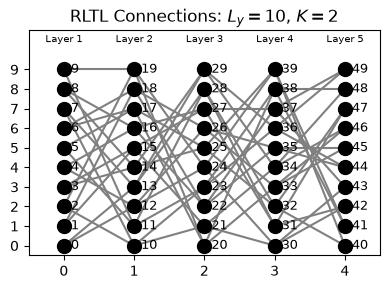

In [81]:
layers_to_plot = 5

fig, ax = plt.subplots(figsize=(4,3))

x_positions = [0, 1, 2, 3, 4]
y_positions = np.arange(Ly)

# Draw the sites
for x in x_positions:
    ax.scatter([x] * Ly, y_positions, s=100, color="black", zorder=3)

# Draw connections 
for layer in range(layers_to_plot - 1):
    Tx = T[layer]

    x1 = x_positions[layer]
    x2 = x_positions[layer + 1]

    for i in range(Ly):
        for j in range(Ly):

            if Tx[i, j] == 1:
                ax.plot([x1, x2], [i, j], color="gray", linewidth=1.5, zorder=1)
                
# Label the layers 
ax.text(0, Ly + 0.4, "Layer 1", ha="center", fontsize=7)
ax.text(1, Ly + 0.4, "Layer 2", ha="center", fontsize=7)
ax.text(2, Ly + 0.4, "Layer 3", ha="center", fontsize=7)
ax.text(3, Ly + 0.4, "Layer 4", ha="center", fontsize=7)
ax.text(4, Ly + 0.4, "Layer 5", ha="center", fontsize=7)

# Label sites
for x in x_positions:
    for y in y_positions:
        ax.text(x + 0.1, y, f"{x * Ly + y}", va="center", fontsize=9)

ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-0.5, Ly + 1)

ax.set_xticks(x_positions)
ax.set_yticks(y_positions)

ax.set_title(f"RLTL Connections: $L_y={Ly}$, $K={K}$")

plt.tight_layout()
plt.show()


In [82]:

# Create random onsite potentials

np.random.seed(0)
# epsilon = np.random.uniform(-W/2, W/2, size=(Lx, Ly))

# print("\nOnsite potential epsilon:")
# print(np.round(epsilon, 2))

epsilon = np.random.uniform(-W/2, W/2, N)


In [83]:
print(np.sum(epsilon))  

-170.83256687823854


# Construct the Hamiltonian

In [84]:

H = np.zeros((N, N))

# Put onsite potentails on the diagonal 

np.fill_diagonal(H, epsilon)
        


In [85]:
# Put the hopping terms between neighboring layers 
for x in range(Lx - 1):

    start1 = x * Ly
    end1 = (x + 1) * Ly 

    start2 = (x + 1) * Ly 
    end2 = (x + 2) * Ly

    H[start1:end1, start2:end2] = J * T[x].T
    H[start2:end2, start1:end1] = J * T[x]
    


In [86]:
print ("\nHamiltonian H:")
print(H)



Hamiltonian H:
[[ 0.48813504  0.          0.         ...  0.          0.
   0.        ]
 [ 0.          2.15189366  0.         ...  0.          0.
   0.        ]
 [ 0.          0.          1.02763376 ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ... -2.22917331  0.
   0.        ]
 [ 0.          0.          0.         ...  0.         -4.44399535
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
  -1.92063747]]


In [87]:
print("\nIs H Hermitian?")
print(np.allclose(H, H.T))


Is H Hermitian?
True


# Plot the Hamiltonian 

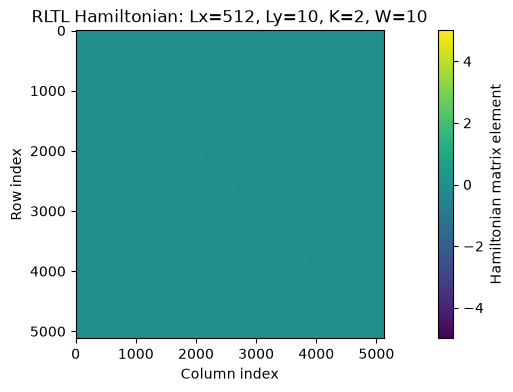

In [88]:
plt.figure(figsize=(14, 4))

plt.imshow(H, interpolation="None")#, cmap="hot", aspect="auto")

plt.colorbar(label="Hamiltonian matrix element")

plt.xlabel("Column index")
plt.ylabel("Row index")

plt.title(f"RLTL Hamiltonian: Lx={Lx}, Ly={Ly}, K={K}, W={W}")
plt.show()


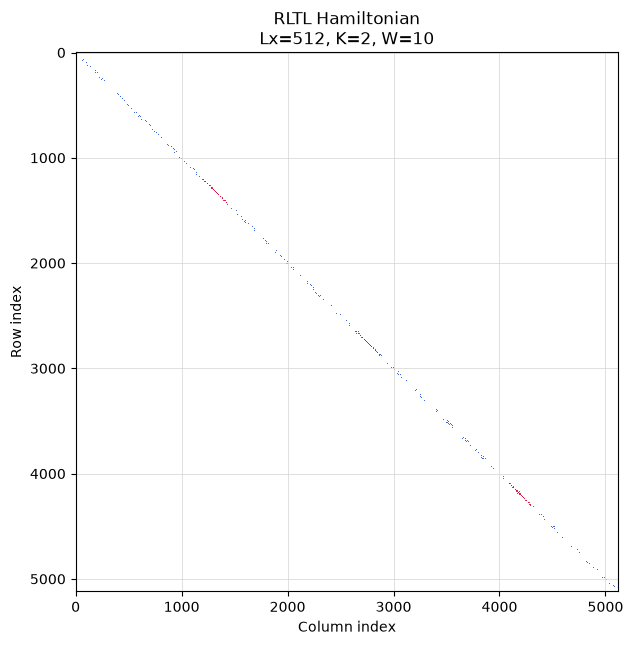

In [89]:
from matplotlib.colors import ListedColormap

# Random onsite potential
np.random.seed(0)
epsilon = np.random.uniform(-W/2, W/2, N)

H = np.zeros((N, N), dtype=float)

# Put onsite potentials on the diagonal 
np.fill_diagonal(H, epsilon)

# plt.imshow(H)
# plt.plot([-0.5, N-0.5], [-0.5, N-0.5], color="red", linewidth=1)  # Diagonal line


# Put the hopping matrices between neighboring layers
for x in range(Lx - 1):

    start1 = x * Ly
    end1 = (x + 1) * Ly 

    start2 = (x + 1) * Ly 
    end2 = (x + 2) * Ly

    # Upper diagonal block 
    H[start1:end1, start2:end2] = J * T[x].T

    # Lower diagonal block 
    H[start2:end2, start1:end1] = J * T[x]


plot_matrix = np.zeros((N, N), dtype=int)
off_diagonal = ~np.eye(N, dtype=bool)
plot_matrix[(H != 0) & off_diagonal] = 1
plot_matrix[np.diag_indices(N)] = 2 



cmap = ListedColormap(["white", "royalblue", "crimson"])

plt.figure(figsize=(7,7))

plt.imshow(plot_matrix, cmap= cmap, interpolation="None", aspect="auto")

plt.xlabel("Column index")
plt.ylabel("Row index")

plt.title(f"RLTL Hamiltonian\n"f"Lx={Lx}, K={K}, W={W}")



plt.grid(True, color="lightgray", linewidth=0.5)

plt.show()



# Diagonalize the Hamiltonian 

eigenvalues near E = 0:
160


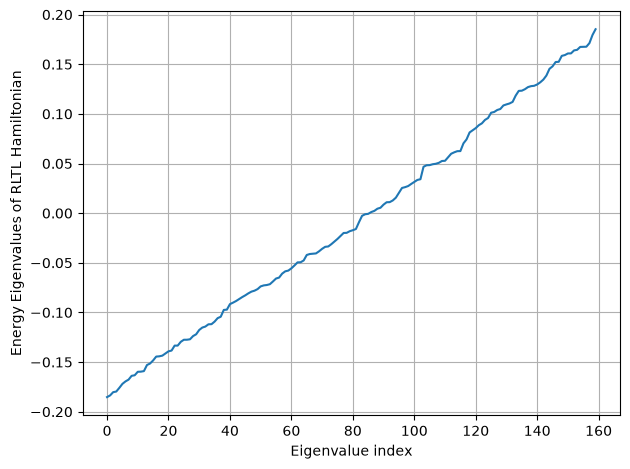

In [90]:
from scipy.sparse.linalg import eigsh

num_eigenvalues = N // 32

eigenvalues, eigenvectors = eigsh(H, k=num_eigenvalues, sigma=0, which="LM")

# print(eigenvalues)
# plt.plot(eigenvalues)

idx = np.argsort(eigenvalues)

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("eigenvalues near E = 0:")
print(eigenvalues.size)

plt.plot(eigenvalues)

plt.xlabel("Eigenvalue index")
plt.ylabel("Energy Eigenvalues of RLTL Hamiltonian")

plt.grid()
plt.tight_layout()
plt.show()

In [91]:
print(eigenvectors.shape)

(5120, 160)


In [92]:
print(np.sum(eigenvalues))  

-1.2829361277710056


# Check that the diagonalization is correct 

In [93]:
n = [0, 1]

for n in range(len(eigenvalues)):
    # print(f"\nEigenvalue {n}: {eigenvalues[n]}")
    # print(f"Eigenvector {n}: {np.round(eigenvectors[:, n], 2)}")

    left = H @ eigenvectors[:, n]
    right = eigenvalues[n] * eigenvectors[:, n]

    print(np.allclose(left, right))

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


# Level-Spacing Ratio

In [94]:
eigenvalues = np.sort(eigenvalues)
spacings = np.diff(eigenvalues)

r = np.minimum(spacings[:-1], spacings[1:]) / \
    np.maximum(spacings[:-1], spacings[1:])

print("Mean level-spacing ratio:",np.mean(r))

Mean level-spacing ratio: 0.4277649815224969


# Inverse Participation Ratio

In [95]:
IPR = np.sum(np.abs(eigenvectors)**4, axis=0)

print("\nIPR of all eigenstates:")
print(IPR)


IPR of all eigenstates:
[0.03077859 0.02204821 0.03133069 0.02759154 0.03039202 0.10281931
 0.11044431 0.01962091 0.05686204 0.04132181 0.04883216 0.11362933
 0.04342157 0.10926056 0.03045796 0.05310582 0.06231574 0.0330849
 0.02523728 0.04333668 0.02317036 0.04195307 0.06258916 0.05625008
 0.02932714 0.03433396 0.05239749 0.03616286 0.0396393  0.04315261
 0.03916169 0.14567295 0.04631996 0.05154564 0.11970637 0.12876235
 0.05638583 0.05198246 0.08927131 0.02982786 0.03982308 0.03028981
 0.02520188 0.06188511 0.04334265 0.03669794 0.03375485 0.05346318
 0.04176403 0.15278803 0.01337267 0.06672801 0.01936472 0.0273547
 0.02533468 0.05442607 0.03330925 0.14118788 0.06886998 0.05134883
 0.03551735 0.02306574 0.07675587 0.05332947 0.01874364 0.04480967
 0.02977015 0.07691772 0.04573854 0.05406189 0.03421036 0.02962624
 0.04226454 0.05513661 0.02795233 0.11146431 0.0299197  0.03803091
 0.04482511 0.02319359 0.07781609 0.03555453 0.05439778 0.05535174
 0.05270259 0.05565491 0.02797434 0.050

In [96]:
Norm = np.sum(np.abs(eigenvectors)**2, axis=0)
print("\nNorm of all eigenstates:")
print(Norm)


Norm of all eigenstates:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [97]:
print ("IPR of n-th eigenstate:")
print(IPR[n])

IPR of n-th eigenstate:
0.02972354565811778


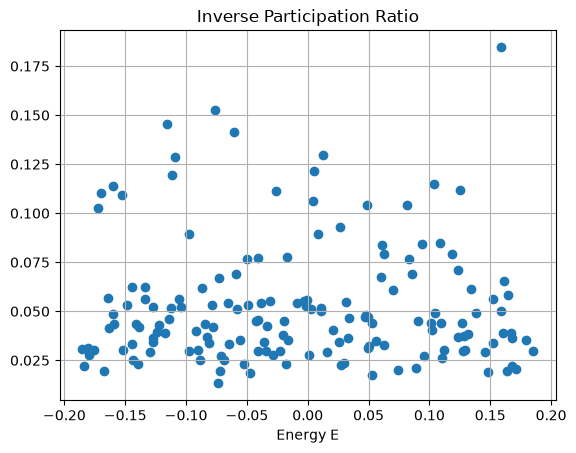

In [98]:
plt.scatter(eigenvalues, IPR)
# plt.plot(eigenvalues, IPR)

plt.xlabel("Energy E")
# plt.ylabel(IPR)
plt.title("Inverse Participation Ratio")
plt.grid()
plt.show()

# Distribution of eigenvalues around E = 0

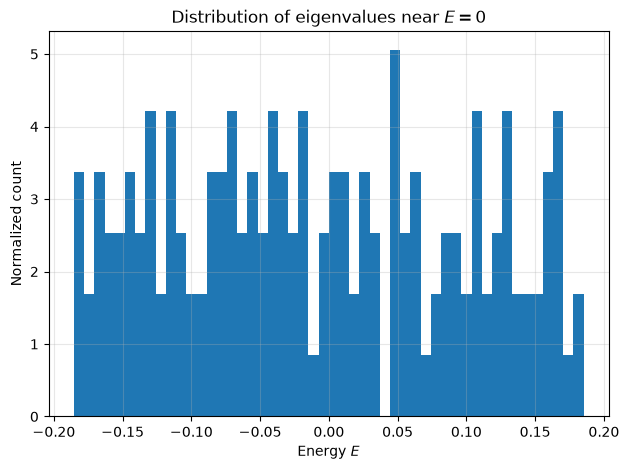

In [99]:
plt.hist(eigenvalues, bins=50, density=20)

plt.xlabel("Energy $E$")
plt.ylabel("Normalized count")

plt.title("Distribution of eigenvalues near $E=0$")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

----

#DOS

In [137]:
Lx = 512
Ly = 10
K = 2
J = 1
W = 10

N = Lx * Ly 

num_T_realizations = 10 
num_epsilon_realizations = 5

np.random.seed(0)

def create_random_T(Ly, K):
    Tx = np.zeros((Ly, Ly), 
                  dtype=int)

    rows = np.arange(Ly)

    for k in range(K):
        Tx[(rows + k) % Ly, rows] = 1

    Tx = Tx[np.random.permutation(Ly)]
    Tx = Tx[:, np.random.permutation(Ly)]

    return Tx


def create_T_realizations():

    T = []

    for x in range(Lx - 1):
        Tx = create_random_T(Ly, K)
        T.append(Tx)

    return T

all_eigenvalues = []

for t_realization in range(num_T_realizations):

    print(
        f"T realization "
        f"{t_realization + 1}/{num_T_realizations}")

    T = create_T_realizations()

    for e_realtization in range(num_epsilon_realizations):
        print(f"epsilon realization"
              f"{e_realtization + 1}/{num_epsilon_realizations}")
        

        H = np.zeros((N, N))

        epsilon = np.random.uniform(-W/2, W/2, N)

        np.fill_diagonal(H, epsilon)

        for x in range(Lx - 1):

            start1 = x * Ly
            end1 = (x + 1) * Ly 

            start2 = (x + 1) * Ly 
            end2 = (x + 2) * Ly

            H[start1:end1, start2:end2] = J * T[x].T
            H[start2:end2, start1:end1] = J * T[x]
    

        eigenvalues = np.linalg.eigvalsh(H)
        all_eigenvalues.extend(eigenvalues)

all_eigenvalues = np.array(all_eigenvalues)

# plt.hist(eigenvalues, bins=50, density=True, edgecolor="black")
# plt.show()


T realization 1/10
epsilon realization1/5
epsilon realization2/5
epsilon realization3/5
epsilon realization4/5
epsilon realization5/5
T realization 2/10
epsilon realization1/5
epsilon realization2/5
epsilon realization3/5
epsilon realization4/5
epsilon realization5/5
T realization 3/10
epsilon realization1/5
epsilon realization2/5
epsilon realization3/5
epsilon realization4/5
epsilon realization5/5
T realization 4/10
epsilon realization1/5
epsilon realization2/5
epsilon realization3/5
epsilon realization4/5
epsilon realization5/5
T realization 5/10
epsilon realization1/5
epsilon realization2/5
epsilon realization3/5
epsilon realization4/5
epsilon realization5/5
T realization 6/10
epsilon realization1/5
epsilon realization2/5
epsilon realization3/5
epsilon realization4/5
epsilon realization5/5
T realization 7/10
epsilon realization1/5
epsilon realization2/5
epsilon realization3/5
epsilon realization4/5
epsilon realization5/5
T realization 8/10
epsilon realization1/5
epsilon realization2

In [138]:
# Calculate DOS
dos, energy_edges = np.histogram(
    all_eigenvalues,
    bins=50,
    density=True
)

# Energy at the center of each bin
energy = (energy_edges[:-1] + energy_edges[1:]) / 2

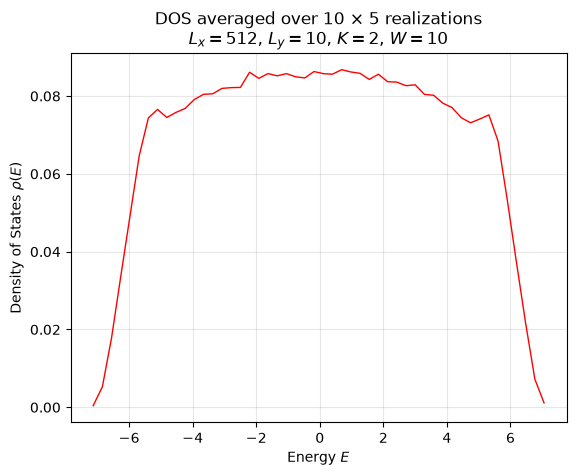

In [139]:
plt.plot(energy, dos, linewidth=1, color="r")

plt.xlabel("Energy $E$")
plt.ylabel("Density of States $\\rho(E)$")

plt.title(
    f"DOS averaged over {num_T_realizations} "
    f"× {num_epsilon_realizations} realizations\n"
    f"$L_x={Lx}$, $L_y={Ly}$, $K={K}$, $W={W}$")

plt.grid(alpha=0.3)

plt.savefig(f"DOS_for Lx={Lx} and Ly={Ly}.png", dpi=300, bbox_inches="tight")
plt.show()

In [126]:
all_eigenvalues = []

for realization in range(10):

    # Generate random onsite potential
    epsilon = np.random.uniform(-W/2, W/2, N)

    H = np.zeros((N, N))

    np.fill_diagonal(H, epsilon)

    # Hopping
    for x in range(Lx - 1):

        start1 = x * Ly
        end1 = (x + 1) * Ly

        start2 = (x + 1) * Ly
        end2 = (x + 2) * Ly

        H[start1:end1, start2:end2] = J * T[x].T
        H[start2:end2, start1:end1] = J * T[x]

    eigenvalues = np.linalg.eigvalsh(H)

    all_eigenvalues.extend(eigenvalues)

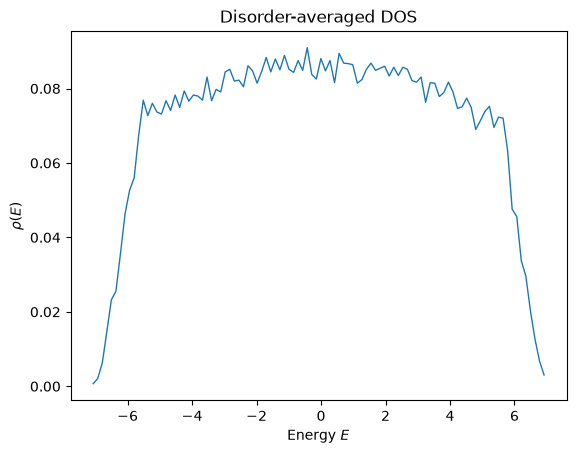

In [128]:
dos, energy_edges = np.histogram(
    all_eigenvalues,
    bins=100,
    density=True
)

energy = (energy_edges[:-1] + energy_edges[1:]) / 2

plt.plot(energy, dos, linewidth=1)

plt.xlabel("Energy $E$")
plt.ylabel("$\\rho(E)$")
plt.title("Disorder-averaged DOS")

plt.show()